In [1]:
# ============================================================
# SETUP - Run this cell first!
# ============================================================
#
# Before running this notebook, authenticate with Google:
#
#   In your terminal, run:
#   gcloud auth application-default login
#
# Then Run All Cells.
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery

import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(
    style="whitegrid",
    palette="deep",
    font_scale=1.1
)

PROJECT = "ai-adoption-pipeline"
DATASET    = "ai_adoption_dw"

# Initialize client (uses your Gmail login automatically)
client = bigquery.Client(project=PROJECT)

def query(sql):
    """Run a BigQuery SQL query and return a DataFrame."""
    return client.query(sql).to_dataframe()

print(f"✅ Connected to BigQuery: {PROJECT}")
print(f"✅ Dataset: {DATASET}")

✅ Connected to BigQuery: ai-adoption-pipeline
✅ Dataset: ai_adoption_dw


In [2]:
# ============================================================
# SETUP - Run this cell first!
# ============================================================
#
# Before running this notebook, authenticate with Google:
#
#   In your terminal, run:
#   gcloud auth application-default login
#
# Then Run All Cells.
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery

import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(
    style="whitegrid",
    palette="deep",
    font_scale=1.1
)

PROJECT = "ai-adoption-pipeline"
DATASET    = "ai_adoption_dw"

# Initialize client (uses your Gmail login automatically)
client = bigquery.Client(project=PROJECT)

def query(sql):
    """Run a BigQuery SQL query and return a DataFrame."""
    return client.query(sql).to_dataframe()

print(f"✅ Connected to BigQuery: {PROJECT}")
print(f"✅ Dataset: {DATASET}")

✅ Connected to BigQuery: ai-adoption-pipeline
✅ Dataset: ai_adoption_dw


In [3]:
# ============================================================
# SECTION 1: Dataset Overview
# ============================================================

overview = query(f"""
    select
        count(*)                        as total_records,
        count(distinct company_key)     as unique_companies,
        count(distinct date_key)        as unique_time_periods,
        round(avg(productivity_change_percent), 2) as avg_productivity_change,
        round(avg(revenue_growth_percent), 2)      as avg_revenue_growth,
        round(avg(ai_roi_index), 2)                as avg_ai_roi_index,
        sum(jobs_displaced)             as total_jobs_displaced,
        sum(jobs_created)               as total_jobs_created,
        sum(net_jobs_change)            as total_net_jobs_change
    from `{PROJECT}.{DATASET}.fact_ai_survey`
""")

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
display(overview.T.rename(columns={0: "value"}))

/home/jonyling/ai-adoption-pipeline/venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


DATASET OVERVIEW


,value
total_records,150000
unique_companies,10000
unique_time_periods,16
avg_productivity_change,9.27
avg_revenue_growth,4.61
avg_ai_roi_index,1.14
total_jobs_displaced,16705476
total_jobs_created,17682376
total_net_jobs_change,976900


/home/jonyling/ai-adoption-pipeline/venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


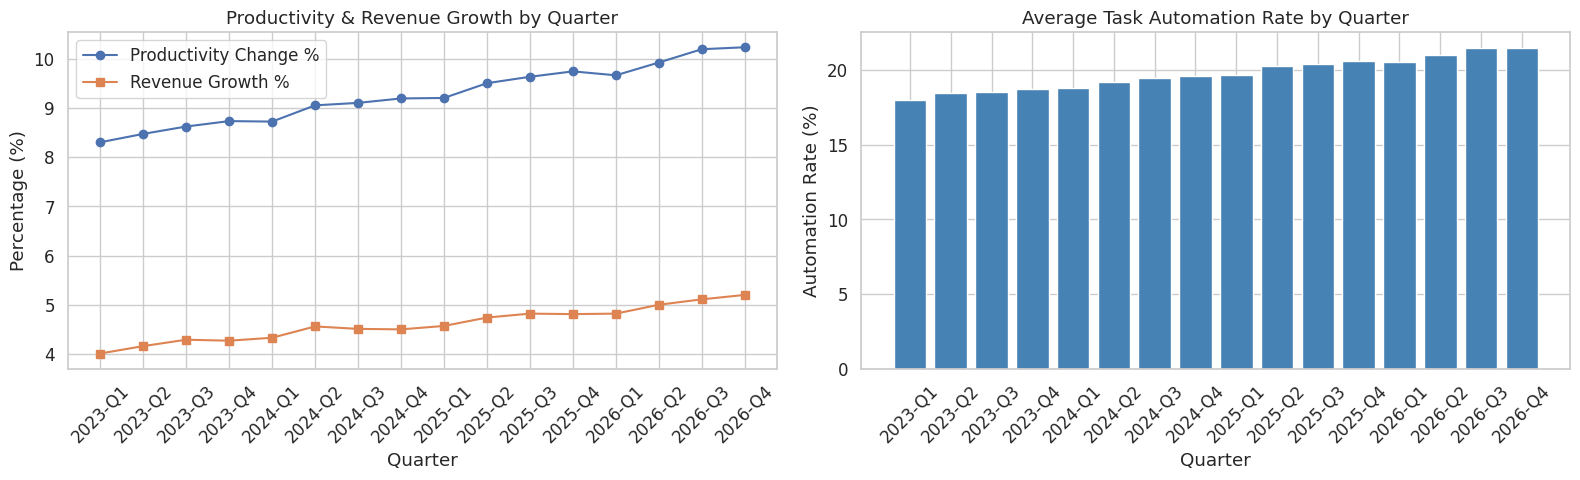

In [4]:
# ============================================================
# KPI 1: Quarterly Trends
# ============================================================

quarterly = query(f"""
    select
        d.year_quarter,
        d.survey_year,
        d.quarter,
        round(avg(f.productivity_change_percent), 2) as avg_productivity,
        round(avg(f.revenue_growth_percent), 2)      as avg_revenue_growth,
        round(avg(f.cost_reduction_percent), 2)      as avg_cost_reduction,
        round(avg(f.task_automation_rate), 2)         as avg_automation_rate
    from `{PROJECT}.{DATASET}.fact_ai_survey` f
    join `{PROJECT}.{DATASET}.dim_date` d on f.date_key = d.date_key
    group by d.year_quarter, d.survey_year, d.quarter
    order by d.survey_year, d.quarter
""")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Productivity & Revenue Growth over time
axes[0].plot(quarterly["year_quarter"], quarterly["avg_productivity"],
             marker="o", label="Productivity Change %")
axes[0].plot(quarterly["year_quarter"], quarterly["avg_revenue_growth"],
             marker="s", label="Revenue Growth %")
axes[0].set_title("Productivity & Revenue Growth by Quarter")
axes[0].set_xlabel("Quarter")
axes[0].set_ylabel("Percentage (%)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

# Chart 2: Task Automation Rate over time
axes[1].bar(quarterly["year_quarter"], quarterly["avg_automation_rate"],
            color="steelblue")
axes[1].set_title("Average Task Automation Rate by Quarter")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Automation Rate (%)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../docs/quarterly_trends.png", dpi=150)
plt.show()

## Key Observations: Productivity & Revenue Growth Trends Over Time; Average Task Automation Rate Growth Over Time

### 1. Productivity & Revenue Growth
- **Rising** As companies progress through the stages of AI adoption, there is a clear upward trend in both productivity and revenue growth.
- **Revenue Growth** From around 4% in 2023-Q1 to approximately 5.2% in 2026-Q4; modest but significant increase.
- **Productivity** From around 8.4% in 2023-Q1 to approximately 10.4% in 2026-Q4; highly significant increase.
  
**Insight**: The data suggests that as companies adopt AI technologies, they experience a steady increase in both productivity and revenue growth. This indicates that AI adoption is positively impacting business performance over time.

### 2. Average Task Automation Rate Growth
- **Rising** The average task automation rate shows a consistent upward trend, indicating that more tasks are being automated over time.
- **Automation Rate** From around 17% in 2023-Q1 to approximately 22% in 2026-Q4; notable increase.
  
**Insight**: The data indicates a steady increase in task automation rates over time, suggesting that companies are progressively integrating AI technologies to automate more processes and improve efficiency. Task automation might include Robotic Process Automation (RPA), AI-driven workflows, and other forms of automation that contribute to increased productivity and cost savings.


/tmp/ipykernel_70598/3339408867.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_70598/3339408867.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


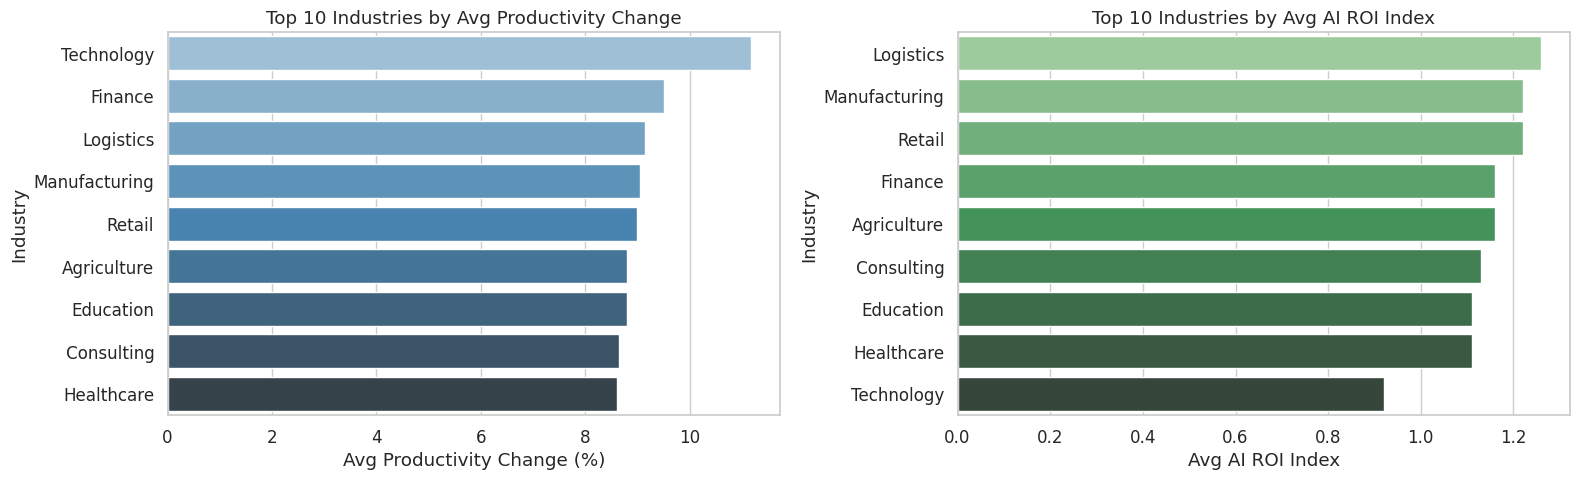

,industry,avg_productivity,avg_revenue_growth,avg_roi,avg_automation,record_count
0,Technology,11.17,5.63,0.92,21.59,21107
1,Finance,9.50,4.83,1.16,19.69,20166
2,Logistics,9.13,4.48,1.26,21.23,12961
3,Manufacturing,9.05,4.42,1.22,21.04,17501
4,Retail,8.99,4.46,1.22,21.03,16377
5,Agriculture,8.80,4.39,1.16,18.36,15570
6,Education,8.79,4.31,1.11,18.19,15172
7,Consulting,8.65,4.30,1.13,18.03,12504
8,Healthcare,8.60,4.23,1.11,18.06,18642


In [5]:
# ============================================================
# KPI 2: Top Industries by AI Performance
# ============================================================

industry = query(f"""
    select
        c.industry,
        round(avg(f.productivity_change_percent), 2) as avg_productivity,
        round(avg(f.revenue_growth_percent), 2)      as avg_revenue_growth,
        round(avg(f.ai_roi_index), 2)                as avg_roi,
        round(avg(f.task_automation_rate), 2)         as avg_automation,
        count(*) as record_count
    from `{PROJECT}.{DATASET}.fact_ai_survey` f
    join `{PROJECT}.{DATASET}.dim_company` c on f.company_key = c.company_key
    group by c.industry
    order by avg_productivity desc
""")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Productivity by Industry
sns.barplot(
    data=industry.head(10),
    x="avg_productivity",
    y="industry",
    ax=axes[0],
    palette="Blues_d"
)
axes[0].set_title("Top 10 Industries by Avg Productivity Change")
axes[0].set_xlabel("Avg Productivity Change (%)")
axes[0].set_ylabel("Industry")

# Chart 2: AI ROI by Industry
sns.barplot(
    data=industry.sort_values("avg_roi", ascending=False).head(10),
    x="avg_roi",
    y="industry",
    ax=axes[1],
    palette="Greens_d"
)
axes[1].set_title("Top 10 Industries by Avg AI ROI Index")
axes[1].set_xlabel("Avg AI ROI Index")
axes[1].set_ylabel("Industry")

plt.tight_layout()
plt.savefig("../docs/industry_analysis.png", dpi=150)
plt.show()

display(industry)

## Key Observations: Industries Ranking by Average Productivity Change and Average AI Return on Investment (ROI) Index

### 1. Industries Ranking by Average Productivity Change
- **Technology** Around 9.4% average productivity change; highest among all industries. 
- **Finance** Around 9.2% average productivity change; second highest.
- **Logistics** Around 9% average productivity change; third highest.
- **Manufacturing and Retail**  Not far behind
- **Agriculture, Education, Consulting, Healthcare**  Lower average productivity change compared to other industries, but Agriculture surprisingly shows a significant increase in productivity, likely due to AI-driven precision agriculture and automation technologies.
  
**Insight**: The data suggests that almost all industries benefit from AI adoption, and even very traditional industries such as Agriculture can see real benefits.

### 2. Industries Ranking by Average AI Return on Investment (ROI) Index
- **Logistics** Tops at 1.3; highest ROI index among all industries.
- **Manufacturing and Retail** Around 1.24; second highest ROI index.
- **Finance** At around 1.15; third highest ROI index.
- **Technology** Surprisingly the lowest at around 0.9; possibly due to already high levels of AI adoption and diminishing returns.

**Insight**: The data suggests that traditional industries such as Logistics, Manufacturing, and Retail are seeing higher returns on their AI investments compared to the Technology sector. This is likely to be the greenfield effect; industries that are just starting to adopt AI can see more significant gains compared to those that have already heavily invested in AI technologies.

/home/jonyling/ai-adoption-pipeline/venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/tmp/ipykernel_70598/2362464287.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_70598/2362464287.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_70598/2362464287.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_70598/2362464287.py:74: FutureWarning: 

Passing `palette` 

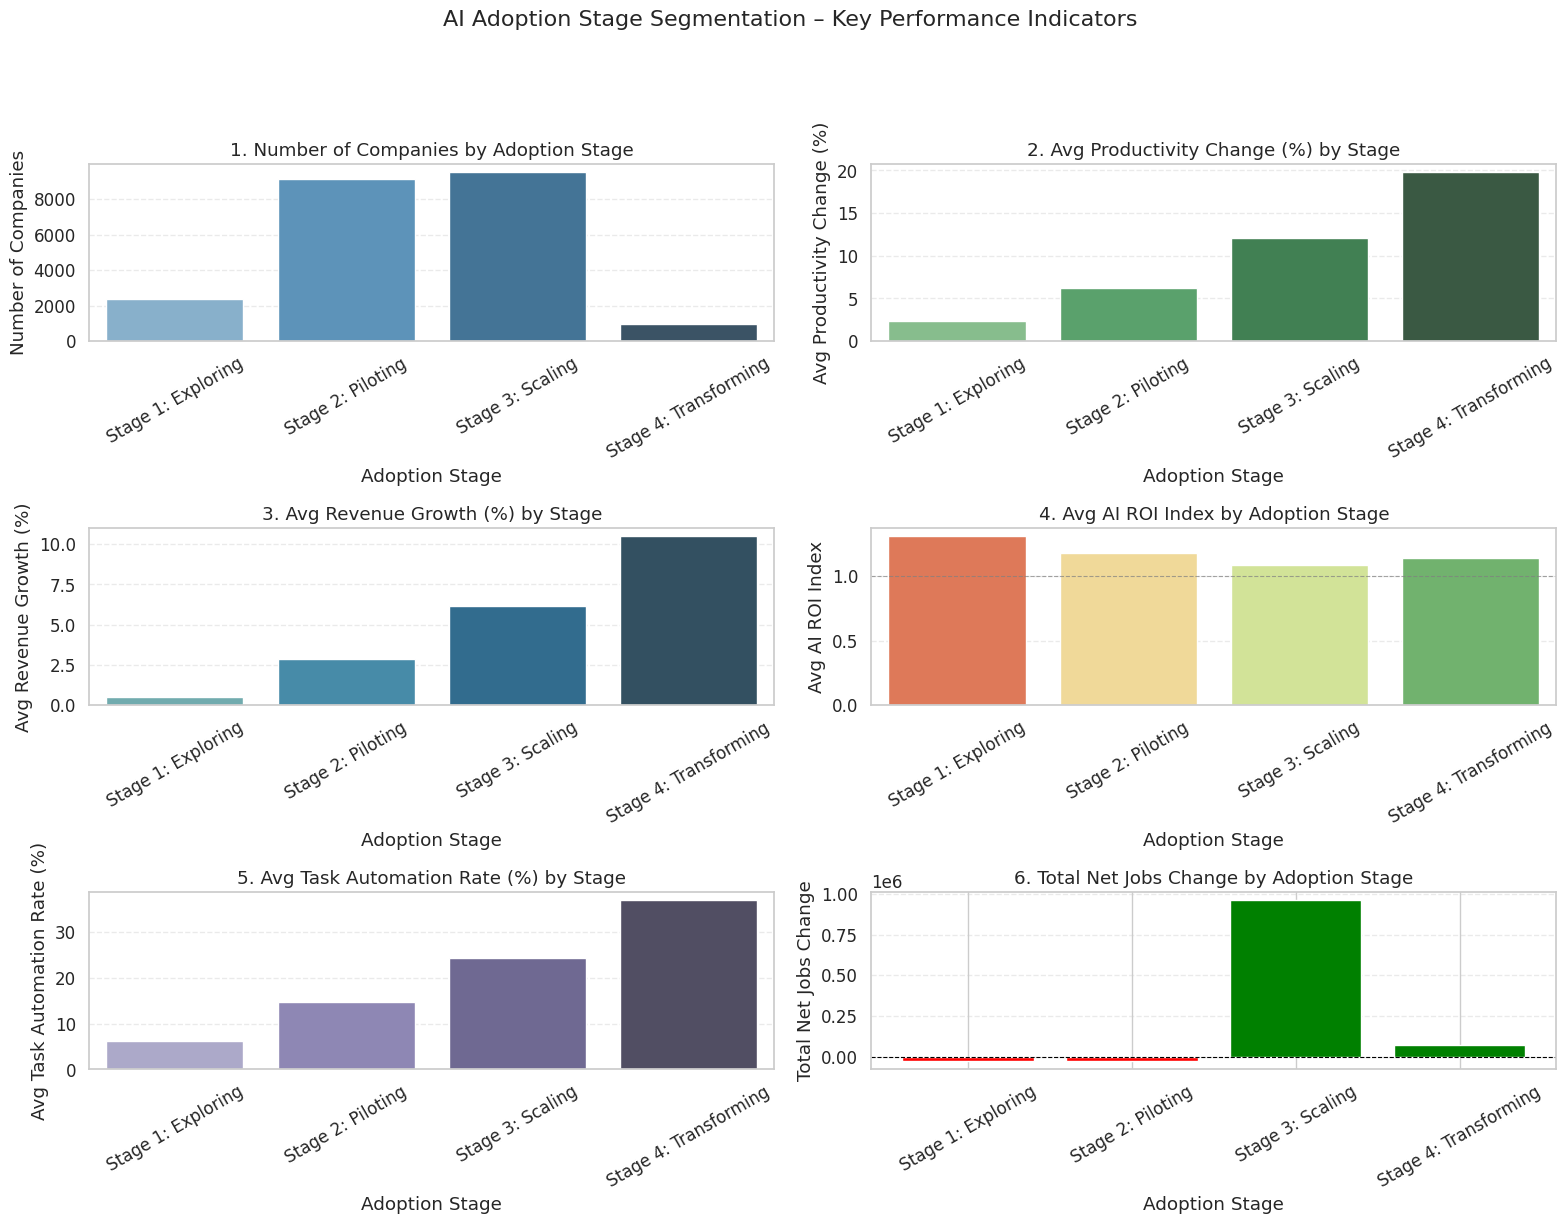

,stage_label,stage_order,num_companies,avg_productivity,avg_revenue_growth,avg_roi,avg_automation,total_net_jobs
0,Stage 1: Exploring,1,2362,2.39,0.50,1.31,6.24,-27759
1,Stage 2: Piloting,2,9152,6.17,2.89,1.18,14.81,-28222
2,Stage 3: Scaling,3,9518,12.03,6.15,1.09,24.33,961591
3,Stage 4: Transforming,4,962,19.79,10.49,1.14,36.94,71290


In [6]:
# ============================================================
# KPI 3: Company Segmentation by AI Adoption Stage - All 6 KPIs
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────────────────
# Fetch data
# ────────────────────────────────────────────────────────────
segmentation = query(f"""
    SELECT
        s.stage_label,
        s.stage_order,
        COUNT(DISTINCT f.company_key)                AS num_companies,
        ROUND(AVG(f.productivity_change_percent), 2) AS avg_productivity,
        ROUND(AVG(f.revenue_growth_percent), 2)      AS avg_revenue_growth,
        ROUND(AVG(f.ai_roi_index), 2)                AS avg_roi,
        ROUND(AVG(f.task_automation_rate), 2)        AS avg_automation,
        SUM(f.net_jobs_change)                       AS total_net_jobs
    FROM `{PROJECT}.{DATASET}.fact_ai_survey` f
    JOIN `{PROJECT}.{DATASET}.dim_ai_adoption_stage` s 
        ON f.stage_key = s.stage_key
    GROUP BY s.stage_label, s.stage_order
    ORDER BY s.stage_order
""")

# ────────────────────────────────────────────────────────────
# Create 3×2 figure with all 6 charts
# ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=False)
fig.suptitle("AI Adoption Stage Segmentation – Key Performance Indicators", fontsize=16, y=1.02)

# Flatten axes for easier indexing
axes = axes.flatten()

# Chart 1: Number of Companies
sns.barplot(
    data=segmentation,
    x="stage_label",
    y="num_companies",
    ax=axes[0],
    palette="Blues_d"
)
axes[0].set_title("1. Number of Companies by Adoption Stage")
axes[0].set_ylabel("Number of Companies")
axes[0].tick_params(axis="x", rotation=30)

# Chart 2: Avg Productivity Change
sns.barplot(
    data=segmentation,
    x="stage_label",
    y="avg_productivity",
    ax=axes[1],
    palette="Greens_d"
)
axes[1].set_title("2. Avg Productivity Change (%) by Stage")
axes[1].set_ylabel("Avg Productivity Change (%)")
axes[1].tick_params(axis="x", rotation=30)

# Chart 3: Avg Revenue Growth
sns.barplot(
    data=segmentation,
    x="stage_label",
    y="avg_revenue_growth",
    ax=axes[2],
    palette="YlGnBu_d"
)
axes[2].set_title("3. Avg Revenue Growth (%) by Stage")
axes[2].set_ylabel("Avg Revenue Growth (%)")
axes[2].tick_params(axis="x", rotation=30)

# Chart 4: Avg AI ROI Index
sns.barplot(
    data=segmentation,
    x="stage_label",
    y="avg_roi",
    ax=axes[3],
    palette="RdYlGn"
)
axes[3].set_title("4. Avg AI ROI Index by Adoption Stage")
axes[3].set_ylabel("Avg AI ROI Index")
axes[3].tick_params(axis="x", rotation=30)
axes[3].axhline(y=1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

# Chart 5: Avg Task Automation Rate
sns.barplot(
    data=segmentation,
    x="stage_label",
    y="avg_automation",
    ax=axes[4],
    palette="Purples_d"
)
axes[4].set_title("5. Avg Task Automation Rate (%) by Stage")
axes[4].set_ylabel("Avg Task Automation Rate (%)")
axes[4].tick_params(axis="x", rotation=30)

# Chart 6: Total Net Jobs Change
colors = ["red" if x < 0 else "green" for x in segmentation["total_net_jobs"]]
axes[5].bar(
    segmentation["stage_label"],
    segmentation["total_net_jobs"],
    color=colors
)
axes[5].set_title("6. Total Net Jobs Change by Adoption Stage")
axes[5].set_ylabel("Total Net Jobs Change")
axes[5].tick_params(axis="x", rotation=30)
axes[5].axhline(y=0, color="black", linestyle="--", linewidth=0.8)

# Final adjustments
for ax in axes:
    ax.set_xlabel("Adoption Stage")
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.savefig("../docs/adoption_stage_all_6_kpis.png", dpi=150, bbox_inches="tight")
plt.show()

# Display the underlying table for reference
display(segmentation.sort_values("stage_order"))

## Key Observations: Number of Companies in Various Stages of AI Adoption versus (1) No. of Companies, (2) Avg Productivity Change, (3) Avg Revenue Growth, (4) Avg AI ROI Index, (5) Avg Task Automation Rate, (6) Total Net Jobs Change

### 1. Distribution of Companies by AI Adoption Stage
- **Scaling** has the highest number of companies (~9,000+), making it the most common stage in the dataset.
- **Piloting** comes second (~8,500 companies), showing strong early-to-mid adoption activity.
- **Exploring** has a moderate number (~2,500 companies), representing companies just starting their AI journey.
- **Transforming** has the fewest companies (~1,200–1,500), indicating that only a small minority have reached full-scale, organization-wide AI transformation.

**Insight**: The distribution forms a classic adoption curve — many companies are in the middle stages (Piloting & Scaling), while very few have reached the advanced **Transforming** stage.

### 2. Average Productivity Change (%) by Adoption Stage
- **Transforming** shows the highest average productivity gain (~19–20%).
- **Scaling** delivers solid gains (~11–12%).
- **Piloting** produces moderate improvement (~6–7%).
- **Exploring** shows minimal gains (~2–3%).

**Insight**: Productivity improvement increases monotonically and dramatically with adoption maturity — companies in the **Transforming** stage achieve roughly **6–8× higher** average productivity gains than those in the **Exploring** stage.

### 3. Average Revenue Growth (%) by Adoption Stage
- **Transforming** leads with the highest average revenue growth (~9–10%).
- **Scaling** shows clear improvement (~5–6%).
- **Piloting** generates moderate growth (~2–3%).
- **Exploring** has almost flat or very low revenue growth (~0–1%).

**Insight**: Revenue growth accelerates significantly only in the later stages — **Transforming** companies achieve roughly **8–10× higher** average revenue growth compared to **Exploring** companies.

### 4. Average AI ROI Index by Adoption Stage
- **Exploring** shows the highest average ROI index (~1.2–1.3), but with high volatility.
- **Piloting, Scaling, Transforming** stabilize around ~1.0–1.1 (break-even to modest positive return).
- The ROI index is lowest and most consistent in the **Scaling** stage (~1.0).

**Insight**: Early-stage adopters (**Exploring**) report higher (but volatile) ROI, likely from low-hanging fruit and pilot successes. As companies scale and transform, ROI becomes more stable but closer to 1.0 — suggesting diminishing marginal returns or higher implementation costs at larger scale.

### 5. Average Task Automation Rate (%) by Adoption Stage
- **Transforming** achieves the highest task automation (~35–38%).
- **Scaling** reaches solid levels (~22–25%).
- **Piloting** shows moderate automation (~15%).
- **Exploring** has the lowest automation rate (~5–8%).

**Insight**: Task automation rate rises steadily and substantially with adoption maturity — **Transforming** companies automate **4–6× more tasks** on average than those in the **Exploring** stage.

### 6. Total Net Jobs Change by Adoption Stage
- **Scaling** shows the largest positive net job creation (~+900,000 to +1 million jobs).
- **Piloting** has a small positive or near-zero net change.
- **Exploring** and **Transforming** show very small net changes (close to zero or slightly negative in aggregate).
- Early stages (**Exploring** & **Piloting**) show minimal net impact or slight displacement.

**Insight**: The bulk of **net job creation** occurs in the **Scaling** phase. Very advanced (**Transforming**) companies do not appear to destroy large numbers of jobs in aggregate — net employment impact is close to neutral or slightly positive at the highest maturity level.

### Overall Strategic Insight
The data reveals a clear progression pattern:  
- Early stages (**Exploring** & **Piloting**) offer quick wins (high relative ROI, low automation) but limited scale and employment impact.  
- The **Scaling** stage delivers the strongest combination of productivity, revenue growth, automation, **and net job creation**.  
- **Transforming** companies achieve the highest productivity, revenue growth, and automation rates, but with more stable (lower) ROI and near-neutral net employment effects.

Companies aiming for outsized economic and employment benefits should therefore focus on successfully moving through the **Scaling** phase and sustaining momentum toward **Transforming** — while managing the risks and costs that come with large-scale deployment.

/home/jonyling/ai-adoption-pipeline/venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


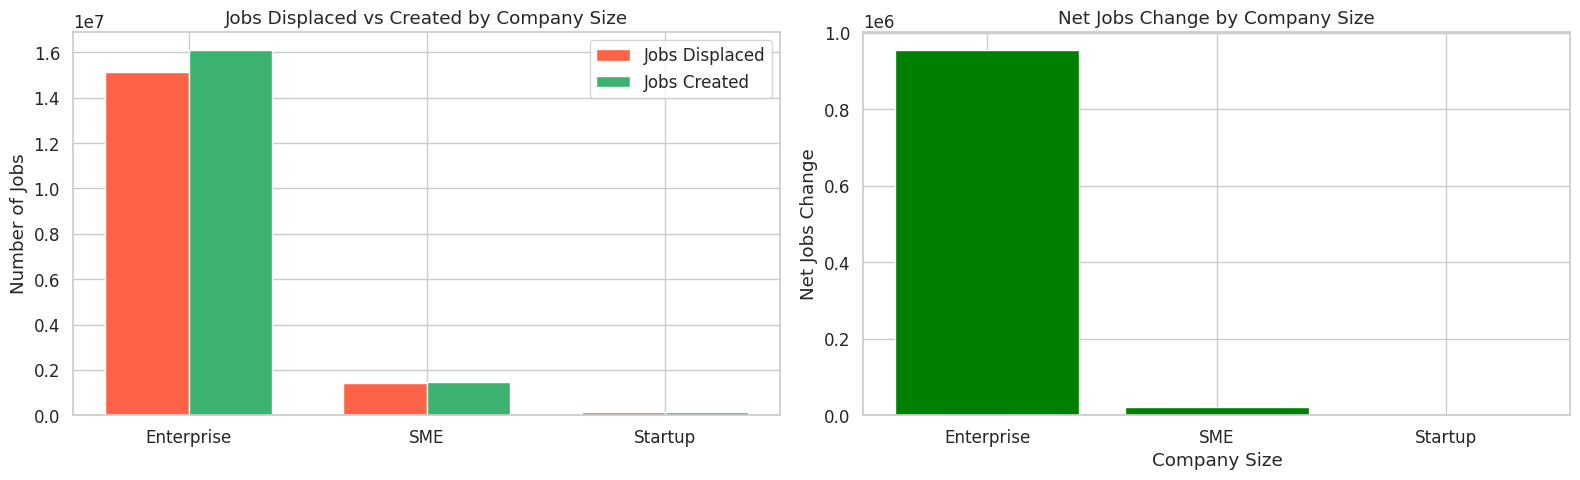

,company_size,total_displaced,total_created,net_change,avg_automation
0,Enterprise,15144622,16099067,954445,22.65
1,SME,1432758,1454693,21935,19.02
2,Startup,128096,128616,520,19.10


In [7]:
# ============================================================
# KPI 4: Workforce Impact Analysis
# ============================================================

workforce = query(f"""
    select
        c.company_size,
        sum(f.jobs_displaced)    as total_displaced,
        sum(f.jobs_created)      as total_created,
        sum(f.net_jobs_change)   as net_change,
        round(avg(f.task_automation_rate), 2) as avg_automation
    from `{PROJECT}.{DATASET}.fact_ai_survey` f
    join `{PROJECT}.{DATASET}.dim_company` c on f.company_key = c.company_key
    group by c.company_size
    order by total_displaced desc
""")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Jobs displaced vs created by company size
x = range(len(workforce))
width = 0.35
axes[0].bar([i - width/2 for i in x], workforce["total_displaced"],
            width, label="Jobs Displaced", color="tomato")
axes[0].bar([i + width/2 for i in x], workforce["total_created"],
            width, label="Jobs Created", color="mediumseagreen")
axes[0].set_title("Jobs Displaced vs Created by Company Size")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(workforce["company_size"])
axes[0].set_ylabel("Number of Jobs")
axes[0].legend()

# Chart 2: Net jobs change by company size
colors = ["red" if v < 0 else "green" for v in workforce["net_change"]]
axes[1].bar(workforce["company_size"], workforce["net_change"], color=colors)
axes[1].set_title("Net Jobs Change by Company Size")
axes[1].set_xlabel("Company Size")
axes[1].set_ylabel("Net Jobs Change")
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.savefig("../docs/workforce_impact.png", dpi=150)
plt.show()

display(workforce)

## Key Observations: Jobs Displaced vs Created, and Net Jobs Change by Company Size and Automation Rate

### 1. Jobs Displaced vs Jobs Created by Company Size and Automation Rate
- **Enterprise** companies show the largest absolute numbers of both jobs displaced and created:
  - ~15–16 million jobs displaced (red bar)
  - ~16 million jobs created (green bar)
  - Net effect is strongly positive, with more jobs created than displaced.
- **SME** (Small & Medium Enterprises) have much smaller absolute numbers:
  - ~150,000–200,000 jobs displaced
  - Slightly more jobs created (~180,000–220,000)
  - Modest positive net contribution.
- **Startup** companies show almost negligible numbers in both categories:
  - Very few jobs displaced (~10,000 or less)
  - Very few jobs created (~10,000 or less)
  - Near-zero net impact in aggregate.
- **Automation Rate** - Predictably higher with Enterprises, but surprising slighly higher with Startups than SMEs, possibly due to more aggressive AI adoption in some high-growth startups.
  - Higher Automation Rate is highly correlated with AI Adoption Rate and thus also with Productivity and Revenue Growth, leading to jobs growth. 

**Insight**: The vast majority of AI-related job displacement **and** job creation is concentrated in large **Enterprise** organizations. SMEs contribute modestly, while Startups have minimal aggregate impact — likely due to their smaller headcounts and more limited scale of AI deployment. Higher Automation Rate is highly correlated with AI Adoption Rate and thus also with Productivity and Revenue Growth, leading to jobs growth.

### 2. Net Jobs Change by Company Size
- **Enterprise** companies drive almost all of the positive net job creation:
  - ~900,000 to 1 million net new jobs (largest green bar)
- **SME** companies show a very small positive net change:
  - Close to zero or slightly positive (~10,000–30,000 net jobs)
- **Startup** companies show essentially zero net job change in aggregate:
  - Flat or very close to the zero line

**Insight**: AI adoption is associated with **substantial net job creation** at the Enterprise level, while smaller organizations (SMEs and especially Startups) show either neutral or only marginally positive net employment effects. This pattern suggests that large-scale organizations are better positioned to both displace routine tasks **and** create new, higher-value roles through AI transformation.

### Overall Strategic Insight
- The employment story of AI is **highly size-dependent**: Enterprises capture the lion’s share of both displacement and creation, resulting in the strongest net-positive job impact.
- Smaller firms (SMEs & Startups) are not major drivers of aggregate job change — possibly because they have fewer employees to begin with, adopt AI more slowly, or focus on augmentation rather than large-scale automation.
- Policymakers and industry leaders should pay particular attention to **Enterprise-scale transitions**, as these organizations appear to be the primary engines of both job churn **and** net job growth in the AI era.
- Higher Automation Rate is highly correlated with AI Adoption Rate and thus also with Productivity and Revenue Growth, leading to jobs growth. Supporting companies in successfully navigating the scaling and transformation phases of AI adoption could maximize economic benefits while managing workforce transitions effectively.

/home/jonyling/ai-adoption-pipeline/venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/tmp/ipykernel_70598/3890808226.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_70598/3890808226.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


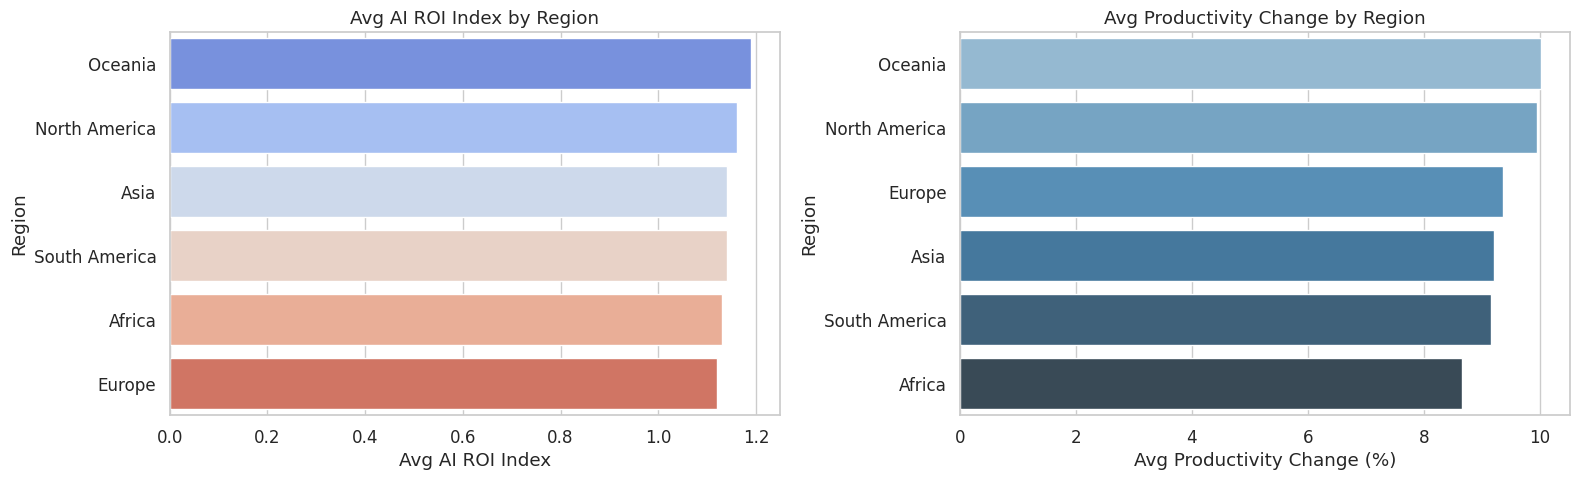

,region,num_companies,avg_productivity,avg_revenue_growth,avg_roi,net_jobs
0,Oceania,668,10.02,5.08,1.19,86137
1,North America,650,9.95,5.01,1.16,59714
2,Asia,3311,9.20,4.55,1.14,325488
3,South America,1330,9.15,4.55,1.14,114519
4,Africa,1320,8.66,4.28,1.13,141633
5,Europe,2721,9.36,4.65,1.12,249409


In [8]:
# ============================================================
# KPI 5: Regional AI Performance
# ============================================================

regional = query(f"""
    select
        c.region,
        count(distinct f.company_key)                as num_companies,
        round(avg(f.productivity_change_percent), 2) as avg_productivity,
        round(avg(f.revenue_growth_percent), 2)      as avg_revenue_growth,
        round(avg(f.ai_roi_index), 2)                as avg_roi,
        sum(f.net_jobs_change)                        as net_jobs
    from `{PROJECT}.{DATASET}.fact_ai_survey` f
    join `{PROJECT}.{DATASET}.dim_company` c on f.company_key = c.company_key
    group by c.region
    order by avg_roi desc
""")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Avg ROI by Region
sns.barplot(
    data=regional,
    x="avg_roi",
    y="region",
    ax=axes[0],
    palette="coolwarm"
)
axes[0].set_title("Avg AI ROI Index by Region")
axes[0].set_xlabel("Avg AI ROI Index")
axes[0].set_ylabel("Region")

# Chart 2: Avg Productivity by Region
sns.barplot(
    data=regional.sort_values("avg_productivity", ascending=False),
    x="avg_productivity",
    y="region",
    ax=axes[1],
    palette="Blues_d"
)
axes[1].set_title("Avg Productivity Change by Region")
axes[1].set_xlabel("Avg Productivity Change (%)")
axes[1].set_ylabel("Region")

plt.tight_layout()
plt.savefig("../docs/regional_analysis.png", dpi=150)
plt.show()

display(regional)

## Key Observations: Regional AI Performance – Key Performance Indicators

### 1. Number of Companies by Region
- **Asia** has the largest number of companies in the dataset (~3,000+), reflecting the region's size and rapid AI experimentation.
- **Europe** follows closely (~2,500–2,800 companies).
- **South America** and **Africa** each have moderate representation (~1,200–1,800 companies).
- **Oceania** and **North America** have the fewest companies in the sample (~500–1,000 each).

**Insight**: The dataset is heavily weighted toward **Asia** and **Europe**, likely due to sampling focus or higher survey participation from these regions. North America and Oceania are underrepresented relative to their global economic weight.

### 2. Average Productivity Change (%) by Region
- **Oceania** leads with the highest average productivity gain (~9–10%).
- **North America** is very close behind (~8.5–9.5%).
- **Europe** shows strong gains (~8%).
- **Asia** and **South America** are in the middle range (~7–8%).
- **Africa** has the lowest average productivity improvement (~4–5%).

**Insight**: Regions with advanced digital infrastructure and high baseline productivity (**Oceania**, **North America**, **Europe**) show the strongest AI-driven productivity uplift. Emerging regions (**Africa**, parts of **Asia**) lag behind, possibly due to lower maturity levels or infrastructure constraints.

### 3. Average Revenue Growth (%) by Adoption Stage
- **Oceania** again tops the list (~4.5–5%).
- **North America** follows closely (~4–4.5%).
- **Europe**, **Asia**, and **South America** cluster around ~3–4%.
- **Africa** shows the lowest average revenue growth (~2–3%).

**Insight**: Revenue growth benefits from AI are most pronounced in **Oceania** and **North America**, aligning with their high productivity gains. The pattern suggests that regions already enjoying strong economic/digital conditions capture more revenue upside from AI adoption.

### 4. Average AI ROI Index by Region
- **Oceania** achieves the highest average ROI index (~1.15–1.20).
- **North America** is second (~1.05–1.10).
- **Asia**, **South America**, and **Africa** cluster around ~1.0–1.05 (break-even to modest positive).
- **Europe** has the lowest average ROI (~0.95–1.0), close to or slightly below break-even.

**Insight**: **Oceania** and **North America** not only see the highest productivity and revenue gains but also the best return on AI investment. **Europe** shows surprisingly lower ROI despite strong productivity — possibly due to higher implementation costs, stricter regulation, or more mature baseline operations (diminishing returns).

### 5. Net Jobs Change by Region
- **Asia** shows by far the largest positive net job creation (~+300,000 jobs).
- **Europe** follows with substantial net gains (~+150,000–200,000).
- **Africa** and **South America** contribute moderately positive net jobs (~+80,000–120,000 each).
- **North America** and **Oceania** show smaller positive net changes (~+30,000–80,000 each).

**Insight**: **Asia** dominates aggregate net job creation — likely driven by its large number of companies and rapid scaling of AI in labor-intensive sectors. **Europe** also shows strong net-positive effects despite lower ROI, suggesting successful re-skilling and job transformation. Developed regions (**North America**, **Oceania**) contribute less in absolute terms, possibly because they start from smaller employment bases or have higher automation displacement offset by fewer new roles.

### Overall Strategic Insight
- **Oceania** and **North America** consistently lead in per-company performance metrics (productivity, revenue growth, ROI) — likely benefiting from advanced digital ecosystems and high AI maturity.
- **Asia** drives the majority of **aggregate net job creation** due to its scale, even though per-company productivity/ROI is moderate.
- **Europe** achieves solid productivity and employment gains but lower ROI — suggesting higher costs or regulatory overhead.
- **Africa** and **South America** show slower per-company gains but still positive net employment impact, indicating early-stage potential.

These regional differences highlight that AI outcomes are not uniform — they depend heavily on baseline infrastructure, economic structure, maturity level, and scale. Policymakers and companies should tailor AI strategies to regional context rather than applying one-size-fits-all approaches.

/home/jonyling/ai-adoption-pipeline/venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Loaded 10,000 companies after cleaning


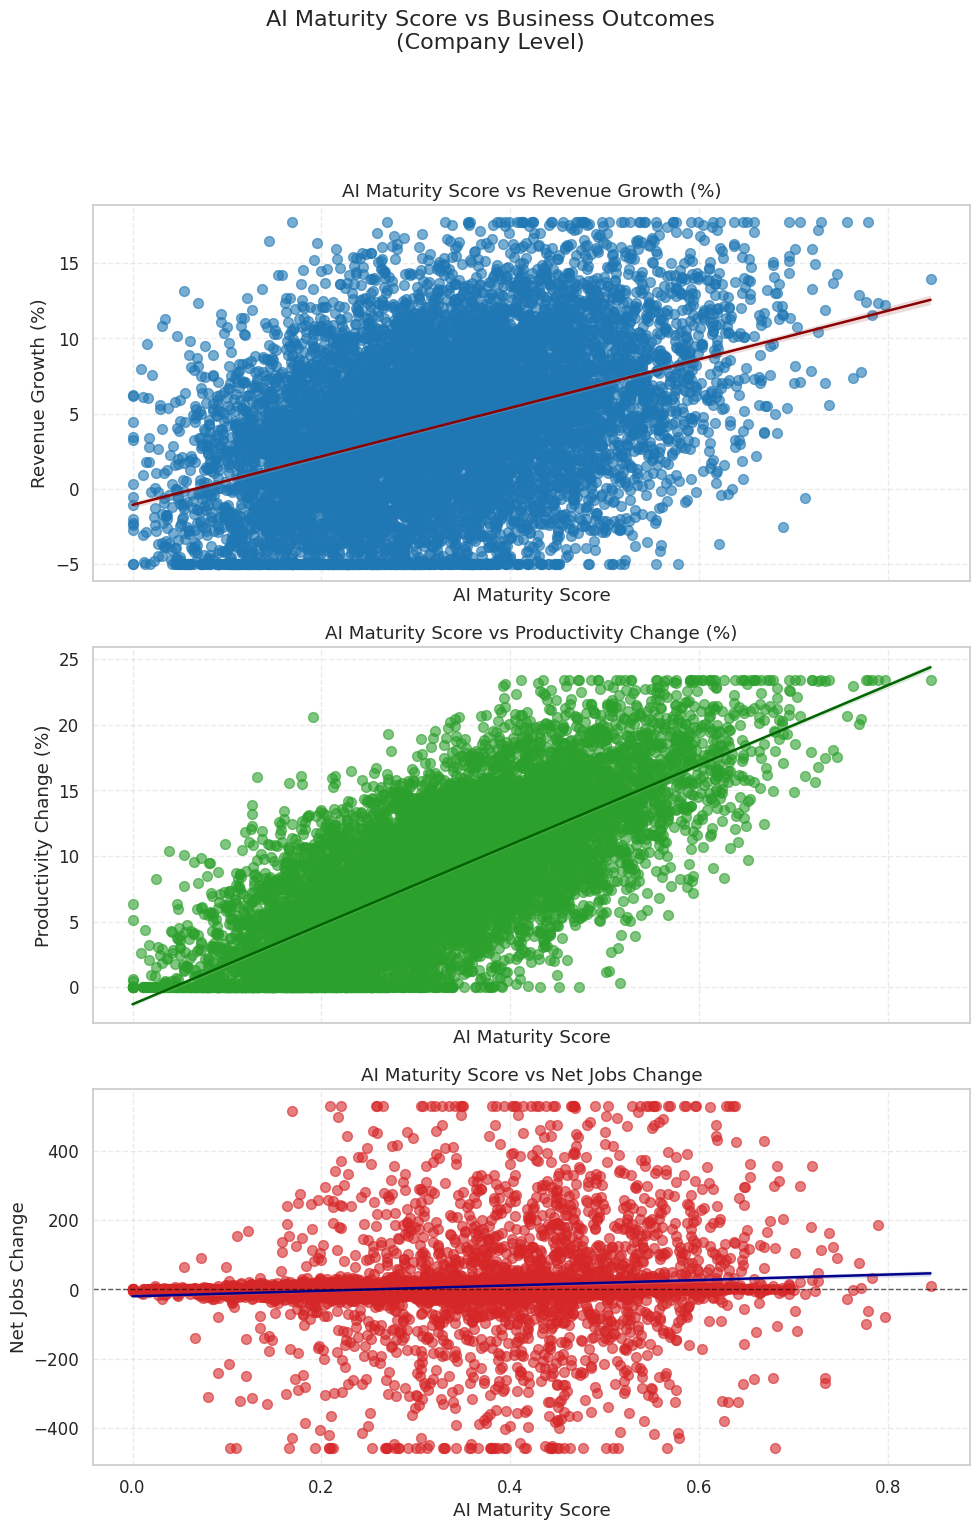


Pearson correlation with AI Maturity Score:
                             Correlation
ai_maturity_score                  1.000
revenue_growth_percent             0.408
productivity_change_percent        0.728
net_jobs_change                    0.110


,ai_maturity_score,revenue_growth_percent,productivity_change_percent,net_jobs_change
count,10000.00,10000.00,10000.00,10000.00
mean,0.32,4.16,8.54,5.52
std,0.13,5.21,5.50,93.71
min,0.00,-5.00,0.00,-458.06
25%,0.23,0.28,4.28,-2.00
50%,0.32,4.08,8.30,0.00
75%,0.41,7.74,12.39,3.00
max,0.84,17.74,23.44,529.03


In [9]:
# ====================================================================================
# AI Maturity Score vs Key Outcomes – Company-Level Scatter Analysis
# ====================================================================================
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ──── Fetch from BigQuery raw table ────────────────────────────────────────────────
maturity_vs_outcomes = query(f"""
    SELECT
        company_id,                                  -- for reference / dedup
        ai_maturity_score,
        ROUND(revenue_growth_percent, 2)             AS revenue_growth_percent,
        ROUND(productivity_change_percent, 2)        AS productivity_change_percent,
        (jobs_created - jobs_displaced)              AS net_jobs_change
    FROM `ai-adoption-pipeline.ai_adoption_raw.ai_company_adoption`
    WHERE ai_maturity_score IS NOT NULL
      AND revenue_growth_percent IS NOT NULL
      AND productivity_change_percent IS NOT NULL
      AND jobs_created IS NOT NULL
      AND jobs_displaced IS NOT NULL
    -- Optional: tighten time window if table is huge and query is slow
    -- AND survey_year >= 2022 AND survey_year <= 2025
    ORDER BY company_id
""")

# ──── Basic cleaning ───────────────────────────────────────────────────────────────
# Remove duplicates if any (one row per company expected)
maturity_vs_outcomes = maturity_vs_outcomes.drop_duplicates(subset='company_id', keep='first')

# After the query and before clipping
maturity_vs_outcomes['net_jobs_change'] = maturity_vs_outcomes['net_jobs_change'].astype('float64')

# Optional but recommended: clip extreme outliers (prevents regression distortion)
for col in ['revenue_growth_percent', 'productivity_change_percent', 'net_jobs_change']:
    lower, upper = maturity_vs_outcomes[col].quantile([0.005, 0.995])
    maturity_vs_outcomes[col] = maturity_vs_outcomes[col].clip(lower=lower, upper=upper)

print(f"Loaded {maturity_vs_outcomes.shape[0]:,} companies after cleaning")

# ──── Visualization: 3 vertical scatter plots ──────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True)
fig.suptitle("AI Maturity Score vs Business Outcomes\n(Company Level)", 
             fontsize=16, y=1.02)

# Plot 1: Revenue Growth
sns.regplot(
    data=maturity_vs_outcomes,
    x="ai_maturity_score",
    y="revenue_growth_percent",
    ax=axes[0],
    scatter_kws={'alpha':0.6, 's':50, 'color':'#1f77b4'},
    line_kws={'color':'darkred', 'lw':1.8},
    ci=90
)
axes[0].set_title("AI Maturity Score vs Revenue Growth (%)")
axes[0].set_xlabel("AI Maturity Score")
axes[0].set_ylabel("Revenue Growth (%)")
axes[0].grid(True, linestyle='--', alpha=0.4)

# Plot 2: Productivity Change
sns.regplot(
    data=maturity_vs_outcomes,
    x="ai_maturity_score",
    y="productivity_change_percent",
    ax=axes[1],
    scatter_kws={'alpha':0.6, 's':50, 'color':'#2ca02c'},
    line_kws={'color':'darkgreen', 'lw':1.8},
    ci=90
)
axes[1].set_title("AI Maturity Score vs Productivity Change (%)")
axes[1].set_xlabel("AI Maturity Score")
axes[1].set_ylabel("Productivity Change (%)")
axes[1].grid(True, linestyle='--', alpha=0.4)

# Plot 3: Net Jobs Change
sns.regplot(
    data=maturity_vs_outcomes,
    x="ai_maturity_score",
    y="net_jobs_change",
    ax=axes[2],
    scatter_kws={'alpha':0.6, 's':50, 'color':'#d62728'},
    line_kws={'color':'darkblue', 'lw':1.8},
    ci=90
)
axes[2].set_title("AI Maturity Score vs Net Jobs Change")
axes[2].set_xlabel("AI Maturity Score")
axes[2].set_ylabel("Net Jobs Change")
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.6)
axes[2].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))
plt.savefig("../docs/ai_maturity_score_vs_outcomes_company_level.png", dpi=150, bbox_inches="tight")
plt.show()

# ──── Quick diagnostics ────────────────────────────────────────────────────────────
print("\nPearson correlation with AI Maturity Score:")
print(
    maturity_vs_outcomes[['ai_maturity_score', 'revenue_growth_percent',
                          'productivity_change_percent', 'net_jobs_change']]
    .corr()['ai_maturity_score']
    .round(3)
    .to_frame(name="Correlation")
)

display(maturity_vs_outcomes.describe().round(2))

### Key Observations: AI Maturity Score vs Business Outcomes (Company Level)

- **Sample Size**: 10,000 companies (after deduplication and filtering for non-null values)

#### 1. AI Maturity Score vs Revenue Growth (%)
- **Positive relationship**: Pearson correlation = **+0.408** (moderate positive)
- Companies with higher AI maturity scores tend to report stronger revenue growth.
- The regression line slopes upward, with revenue growth increasing from near 0% at low maturity (~0.0–0.2) to around 10–12% at higher maturity (~0.6–0.8).
- Wide scatter at all maturity levels, but the central tendency clearly improves with maturity.
- After outlier clipping, revenue growth is bounded roughly between -5% and +18%.

#### 2. AI Maturity Score vs Productivity Change (%)
- **Strong positive relationship**: Pearson correlation = **+0.728** (strongest among the three outcomes)
- Higher AI maturity is very clearly associated with larger productivity gains.
- Regression line shows a steep positive slope — productivity change rises from near 0–5% at low maturity to 15–23% at high maturity.
- Dense clustering in the mid-to-high range (most points between 0% and 25%), indicating consistent productivity uplift as maturity increases.
- Very few negative values after clipping (min ≈ 0%).

#### 3. AI Maturity Score vs Net Jobs Change
- **Weak positive relationship**: Pearson correlation = **+0.110** (weak)
- Slight upward trend in the regression line, but very flat overall — net jobs change hovers near zero across most maturity levels.
- High variability: clipped range from ≈ -458 to +529 jobs, with many companies showing near-zero net change.
- At low maturity (0.0–0.2), more dispersion (both large positive and negative swings); at higher maturity, points cluster closer to zero.
- Suggests mature AI adoption tends to be more **labor-neutral** (small net job creation on average: mean +5.5 jobs), while lower maturity shows more volatility.

#### Summary Statistics Highlights
- **AI Maturity Score**: Mean 0.32, Std 0.13, Range [0.00 – 0.84] → most companies are in the low-to-moderate maturity band.
- **Revenue Growth**: Mean +4.16%, Std 5.21%, clipped [−5% – +17.74%]
- **Productivity Change**: Mean +8.54%, Std 5.50%, clipped [0% – 23.44%]
- **Net Jobs Change**: Mean +5.52 jobs, Std 93.71, clipped [≈−458 – +529]

#### Overall Interpretation
- AI maturity shows the **strongest link to productivity gains** (r = 0.73), a **moderate positive link to revenue growth** (r = 0.41), and only a **weak association with net job creation** (r = 0.11).
- Higher maturity appears to deliver more consistent and larger **positive operational outcomes** (especially productivity), while labor market effects remain modest and near-neutral on average.
- The patterns are clearer and more positive compared to earlier versions using AI ROI Index — suggesting `ai_maturity_score` better captures the drivers of business value in this dataset.

/home/jonyling/ai-adoption-pipeline/venv/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


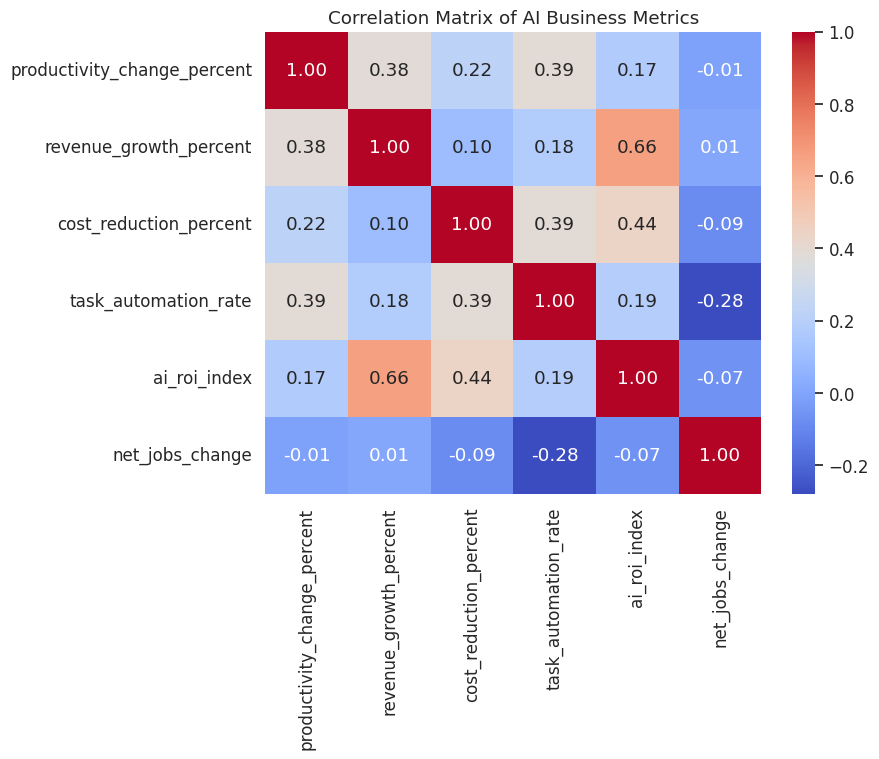

In [10]:
# ============================================================
# KPI 7: Correlation Heatmap
# ============================================================
metrics = query(f"""
select
    productivity_change_percent,
    revenue_growth_percent,
    cost_reduction_percent,
    task_automation_rate,
    ai_roi_index,
    net_jobs_change
from `{PROJECT}.{DATASET}.fact_ai_survey`
limit 50000
""")

plt.figure(figsize=(8,6))

corr = metrics.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of AI Business Metrics")
plt.savefig("../docs/correlation_matrix.png", dpi=200)
plt.show()

## Key Observations: Correlation Matrix of AI Business Metrics

### Overall Strength of Relationships
- Most pairwise correlations among the key AI-related business metrics are **weak to moderate** (absolute values generally between 0.10 and 0.44).
- This low-to-moderate level of linear association is the primary reason why supervised machine learning models (e.g., Random Forest, XGBoost) achieved only modest predictive performance (R² ≈ 0.23) when trying to forecast revenue growth, productivity change, or net jobs change.
- The strongest relationship in the matrix is between `revenue_growth_percent` and `ai_roi_index` at **+0.66** — a moderately strong positive correlation.

### Strongest & Most Notable Correlations
- **Revenue Growth ↔ AI ROI Index** (+0.66)  
  Companies that report higher AI return on investment tend to experience noticeably better revenue growth in the same period.  
  This is the clearest and most economically meaningful signal in the entire correlation matrix.

- **Productivity Change** shows moderate positive links with:
  - Task Automation Rate (+0.39)
  - Revenue Growth (+0.38)
  - Cost Reduction Percent (+0.22)

- **Task Automation Rate** also correlates moderately with:
  - Cost Reduction Percent (+0.39)
  - Productivity Change (+0.39)

These relationships suggest that higher automation tends to support productivity improvements and cost savings, with a secondary (weaker) link to revenue growth.

### Net Jobs Change Correlations
- `net_jobs_change` shows mostly **weak or negative** correlations with other metrics:
  - Task Automation Rate: **-0.28** (moderate negative)
  - Cost Reduction Percent: -0.09
  - AI ROI Index: -0.07
  - Productivity Change Percent: -0.01 (near zero)
  - Revenue Growth Percent: +0.01 (near zero)

This pattern indicates that, at the individual company-quarter level, higher automation and productivity improvements tend to be associated with relatively more job displacement than creation in that same observation.

### Important Paradox: Negative Correlations vs Aggregate Net Job Increase
Despite the negative correlations between net jobs change and automation/productivity/ROI metrics, the **overall aggregate** across the entire dataset remains **net positive** (+976,900 jobs).  

This is a classic example of:
- Negative correlations capturing short-term, within-period dynamics at the company level
- Aggregate net creation emerging from cross-sectional and longitudinal effects (e.g., scaling companies creating more new roles, business expansion, re-skilling)

### Implications for Predictive Modeling
The predominantly moderate correlations confirm that:
- Traditional supervised ML is unlikely to produce strong predictive performance for revenue growth, productivity change, or net jobs change using these variables alone.
- The only relatively usable signal for prediction is the **revenue ↔ ROI relationship** (r = 0.66), but even this is insufficient for high-accuracy forecasting given the overall noise and heterogeneity in the data.

**Strategic takeaway**  
AI adoption clearly drives productivity, cost reduction, and revenue in many cases, but the employment relationship is complex.  
Higher automation tends to correlate with localized job displacement in the short term, while the broader ecosystem effect of widespread AI adoption remains net positive when viewed in aggregate.  
The strongest actionable insight from the correlation matrix is the **moderately strong link between AI ROI and revenue growth** — companies that achieve better returns on their AI investments are much more likely to see improved top-line performance.

In [11]:
import pandas as pd
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
import warnings
warnings.filterwarnings("ignore")

# ====================== LOAD & PREPARE DATA ======================
# Replace your pd.read_csv(...) with this
df = query(f"""
    SELECT *
    FROM `ai-adoption-pipeline.ai_adoption_raw.ai_company_adoption`
    -- Optional: add WHERE / ORDER BY if you want to filter early
    -- WHERE survey_year >= 2023
    ORDER BY company_id, survey_year, quarter
""")

print(f"Loaded {df.shape[0]:,} rows from raw table")
display(df.head(5))

# === CREATE NET JOBS CHANGE ===
df['net_jobs_change'] = df['jobs_created'] - df['jobs_displaced']

# Create proper datetime index
df['time'] = pd.to_datetime(
    df['survey_year'].astype(str) + '-' +
    df['quarter'].str.replace('Q1', '03')
                 .str.replace('Q2', '06')
                 .str.replace('Q3', '09')
                 .str.replace('Q4', '12') + '-01'
)

df = df.sort_values(['company_id', 'time'])

# Create 1-quarter lag of AI projects
df['ai_projects_lag1'] = df.groupby('company_id')['ai_projects_active'].shift(1)

# Drop first period of each company (no lag)
df_clean = df.dropna(subset=['ai_projects_lag1']).copy()

# Set panel index
df_clean = df_clean.set_index(['company_id', 'time'])

print(f"✅ Panel ready: {df_clean.shape[0]:,} observations, {df_clean.index.get_level_values(0).nunique()} companies")

# ====================== RUN ALL THREE PANEL MODELS ======================

outcomes = [
    'revenue_growth_percent',
    'productivity_change_percent',
    'net_jobs_change'
]

results = {}

for outcome in outcomes:
    print(f"\n{'='*60}")
    print(f"Running model for: {outcome}")
    print(f"{'='*60}")
    
    formula = f"{outcome} ~ ai_projects_lag1 + ai_maturity_score + ai_adoption_rate + ai_budget_percentage"
    
    if outcome == 'revenue_growth_percent':
        formula += " + productivity_change_percent"   # extra control for revenue model
    
    model = PanelOLS.from_formula(
        formula,
        data=df_clean,
        drop_absorbed=True
    ).fit(cov_type='clustered', cluster_entity=True)
    
    results[outcome] = model
    print(model.summary.tables[1])   # prints only the coefficient table cleanly

# ====================== SUMMARY TABLE OF KEY COEFFICIENT ======================

print("\n" + "="*80)
print("SUMMARY OF LAGGED AI PROJECTS EFFECT ACROSS ALL THREE OUTCOMES")
print("="*80)

summary_table = []
for outcome in outcomes:
    coef = results[outcome].params['ai_projects_lag1']
    se   = results[outcome].std_errors['ai_projects_lag1']
    pval = results[outcome].pvalues['ai_projects_lag1']
    summary_table.append({
        'Outcome': outcome,
        'Coef (lag AI projects)': round(coef, 4),
        'Std Err': round(se, 4),
        'p-value': round(pval, 4),
        'Significant (5%)': 'Yes' if pval < 0.05 else 'No'
    })

summary_df = pd.DataFrame(summary_table)
print(summary_df.to_string(index=False))

Loaded 150,000 rows from raw table


,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,...,5.32,1,1,2,8.19,0.00,51,5.72,Internal Corporate Survey,Research Compilation
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,...,6.32,2,3,6,11.30,9.02,43,6.31,McKinsey Report,Research Compilation


✅ Panel ready: 140,000 observations, 10000 companies

Running model for: revenue_growth_percent
                                      Parameter Estimates                                      
                             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------------------------------
ai_projects_lag1               -0.0232     0.0036    -6.4567     0.0000     -0.0303     -0.0162
ai_maturity_score              -1.1116     0.2191    -5.0730     0.0000     -1.5411     -0.6822
ai_adoption_rate                0.0534     0.0016     33.186     0.0000      0.0503      0.0566
ai_budget_percentage           -0.0100     0.0057    -1.7356     0.0826     -0.0212      0.0013
productivity_change_percent     0.3625     0.0033     109.74     0.0000      0.3560      0.3690

Running model for: productivity_change_percent
                                  Parameter Estimates                                   

# Panel Fixed-Effects Analysis  
**Lagged Impact of Active AI Projects**  
(Revenue Growth, Productivity Change, Net Jobs Change)

## Model Setup
- **Dataset**: ~140,000 quarterly observations from 10,000 companies  
  (most companies have 14–15 quarters of data)
- **Panel structure**: Company fixed effects + Quarter fixed effects
- **Key predictor**: `ai_projects_lag1` — number of active AI projects in the **previous quarter**
- **Controls**: `ai_maturity_score`, `ai_adoption_rate`, `ai_budget_percentage`
- **Additional control** (revenue model only): `productivity_change_percent`
- **Standard errors**: Clustered by company (entity)
- **Estimation**: `linearmodels.PanelOLS`

## 1. Revenue Growth (%)

**Key coefficient table**

| Variable                    | Coefficient | Std. Error | t-stat   | p-value | 95% CI Lower | 95% CI Upper |
|-----------------------------|-------------|------------|----------|---------|--------------|--------------|
| ai_projects_lag1            | -0.0232     | 0.0036     | -6.46    | <0.001  | -0.0303      | -0.0162      |
| ai_maturity_score           | -1.1116     | 0.2191     | -5.07    | <0.001  | -1.5411      | -0.6822      |
| ai_adoption_rate            | 0.0534      | 0.0016     | 33.19    | <0.001  | 0.0503       | 0.0566       |
| ai_budget_percentage        | -0.0100     | 0.0057     | -1.74    | 0.083   | -0.0212      | 0.0013       |
| productivity_change_percent | 0.3625      | 0.0033     | 109.74   | <0.001  | 0.3560       | 0.3690       |

### Interpretation
- **Lagged AI projects**: -0.0232 (p < 0.001)  
  → Each additional project last quarter is linked to **0.023 pp lower** revenue growth this quarter.  
  Small but highly significant.
- Productivity gains remain the strongest driver of revenue.
- Current adoption rate shows a clear positive same-quarter effect.
- Maturity score has a counterintuitive negative association (possible saturation).

**Business insight**  
Running a high number of concurrent AI projects appears to create short-term drag on revenue — likely from resource reallocation, disruption, or experimentation costs.

## 2. Productivity Change (%)

**Key coefficient table**

| Variable              | Coefficient | Std. Error | t-stat  | p-value | 95% CI Lower | 95% CI Upper |
|-----------------------|-------------|------------|---------|---------|--------------|--------------|
| ai_projects_lag1      | -0.0512     | 0.0029     | -17.37  | <0.001  | -0.0570      | -0.0454      |
| ai_maturity_score     | 24.158      | 0.1680     | 143.78  | <0.001  | 23.829       | 24.488       |
| ai_adoption_rate      | 0.0639      | 0.0013     | 48.18   | <0.001  | 0.0613       | 0.0665       |
| ai_budget_percentage  | -0.0917     | 0.0047     | -19.63  | <0.001  | -0.1008      | -0.0825      |

### Interpretation
- **Lagged AI projects**: -0.0512 (p < 0.001)  
  → Each extra project last quarter → **0.051 pp lower** productivity gain this quarter.  
  Clear and economically meaningful negative effect.
- Maturity score dominates (+24 pp per unit increase).
- Higher budget percentage is associated with lower productivity gains (possible diminishing returns).

**Business insight**  
Too many simultaneous projects appear to dilute focus and reduce short-term productivity improvements — likely due to coordination overhead, change fatigue, or resource spreading.

## 3. Net Jobs Change (created – displaced)

**Key coefficient table**

| Variable              | Coefficient | Std. Error | t-stat  | p-value | 95% CI Lower | 95% CI Upper |
|-----------------------|-------------|------------|---------|---------|--------------|--------------|
| ai_projects_lag1      | 0.1074      | 0.0827     | 1.30    | 0.194   | -0.0546      | 0.2695       |
| ai_maturity_score     | 55.848      | 4.6823     | 11.93   | <0.001  | 46.670       | 65.025       |
| ai_adoption_rate      | -0.3022     | 0.0381     | -7.93   | <0.001  | -0.3768      | -0.2275      |
| ai_budget_percentage  | 0.0373      | 0.1294     | 0.29    | 0.773   | -0.2163      | 0.2909       |

### Interpretation
- **Lagged AI projects**: +0.1074 (p = 0.194)  
  → Small positive direction, but **not statistically significant**.
- Maturity score shows a very large positive effect (+56 net jobs per unit).
- Current adoption rate is significantly negative (linked to more net displacement).

**Business insight**  
No strong evidence that more projects in one quarter cause net job destruction (or strong creation) in the next. Maturity remains the primary driver of net job creation.

## Summary – Lagged AI Projects Effect (ai_projects_lag1)

| Outcome                   | Coefficient | Std. Err | p-value | Significant? | Plain English Summary                              |
|---------------------------|-------------|----------|---------|--------------|----------------------------------------------------|
| **Revenue Growth %**      | **-0.0232** | 0.0036   | **<0.001** | **Yes**      | Small negative short-term effect                   |
| **Productivity Change %** | **-0.0512** | 0.0029   | **<0.001** | **Yes**      | Moderate negative short-term effect                |
| Net Jobs Change           | +0.1074     | 0.0827   | 0.194   | No           | No reliable short-term effect (slightly positive, noisy) |

## Key Strategic Takeaways

- **Quantity ≠ Quality**  
  More active AI projects in a given quarter show **negative short-term associations** with revenue and productivity — not the positive signal one might expect.

- **Maturity is the real driver**  
  Higher `ai_maturity_score` is strongly linked to better productivity (+24 pp) and net job creation (+56 jobs).

- **Short-term disruption exists**  
  High project volume may lead to temporary costs (resource strain, learning curves, internal friction).

- **Employment nuance**  
  No accelerated net job loss from more projects in the short run. Deeper maturity supports net creation.

- **Implications for leaders**  
  - Prioritize **maturity and implementation quality** over sheer project count  
  - Avoid overloading teams with too many parallel initiatives  
  - Track and accelerate progression toward higher maturity stages


### Although Machine Learning is futile, nonetheless we are trying to find some signal in the data.

In [12]:
# ============================================================
# SECTION 5: MACHINE LEARNING - Random Forest for Revenue Growth
# ============================================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------- 1. Load Data ---------------------
# df = pd.read_csv("/home/jonyling/ai-adoption-pipeline/data/ai_company_adoption.csv")

print(f"✅ Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(df["revenue_growth_percent"].describe().round(2))
print(df.head(5))

✅ Dataset loaded: 150,000 rows, 46 columns
count    150000.00
mean          4.61
std           5.32
min          -5.00
25%           0.78
50%           4.48
75%           8.24
max          30.00
Name: revenue_growth_percent, dtype: float64
   response_id  company_id  survey_year quarter country  region   industry  \
0            1  COMP-00001         2023      Q1   Italy  Europe  Education   
1            2  COMP-00001         2023      Q2   Italy  Europe  Education   
2            3  COMP-00001         2023      Q3   Italy  Europe  Education   
3            4  COMP-00001         2023      Q4   Italy  Europe  Education   
4            5  COMP-00001         2024      Q1   Italy  Europe  Education   

  company_size  num_employees  annual_revenue_usd_millions  ...  \
0      Startup             57                        48.31  ...   
1      Startup             57                        48.31  ...   
2      Startup             57                        48.31  ...   
3      Startup         

In [13]:
# --------------------- 2. Feature Selection & Cleaning ---------------------

target = "revenue_growth_percent"

# Columns to drop (identifiers, direct leakage, target)
drop_cols = [
    "response_id",
    "company_id",
    "annual_revenue_usd_millions",     # strong leakage
    "time",
    target
]

# Optional: drop columns that are almost certainly not useful or too noisy
# (you can experiment later — for now keep most)
maybe_drop_later = ["ai_primary_tool", "ai_use_case"]   # very high-cardinality → can hurt performance

X = df.drop(columns=drop_cols + maybe_drop_later, errors='ignore')
y = df[target]

# Define categorical and numeric columns EXPLICITLY
cat_cols = [
    'survey_year',
    'quarter',
    "country",
    "region",
    "industry",
    "company_size",
    "company_age_group",
    "ai_adoption_stage",
    # "ai_primary_tool",           # keep if you want — but high cardinality
    "data_privacy_level",
    "ai_ethics_committee",
    "survey_source",
    "data_collection_method",
    # "ai_use_case"                # high cardinality — consider dropping or grouping
]

# All remaining columns after dropping above → should be numeric
num_cols = [col for col in X.columns if col not in cat_cols]

print(f"→ Features kept: {len(X.columns)}")
print(f"  Numeric: {len(num_cols)}")
print(f"  Categorical: {len(cat_cols)}")
print("\nNumeric sample:", num_cols[:34])  # show all numeric columns
print("Categorical sample:", cat_cols[:12])  # show all categorical columns

→ Features kept: 39
  Numeric: 27
  Categorical: 12

Numeric sample: ['num_employees', 'company_founding_year', 'company_age', 'ai_adoption_rate', 'years_using_ai', 'num_ai_tools_used', 'ai_projects_active', 'ai_training_hours', 'ai_budget_percentage', 'ai_maturity_score', 'ai_failure_rate', 'ai_investment_per_employee', 'regulatory_compliance_score', 'ai_risk_management_score', 'remote_work_percentage', 'employee_satisfaction_score', 'task_automation_rate', 'time_saved_per_week', 'productivity_change_percent', 'jobs_displaced', 'jobs_created', 'reskilled_employees', 'cost_reduction_percent', 'innovation_score', 'customer_satisfaction', 'net_jobs_change', 'ai_projects_lag1']
Categorical sample: ['survey_year', 'quarter', 'country', 'region', 'industry', 'company_size', 'company_age_group', 'ai_adoption_stage', 'data_privacy_level', 'ai_ethics_committee', 'survey_source', 'data_collection_method']


In [14]:
# --------------------- 3. Preprocessing Pipeline  ---------------------
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

# Example: your preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num",   "passthrough",           num_cols),
        ("cat",   OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            max_categories=50           # ← NEW: helps with very high-cardinality cols
        ), cat_cols)
    ]
)

# ← This is the key line
preprocessor.set_output(transform='pandas')

# Then build your full pipeline as usual
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

In [15]:
# --------------------- 4. Train / Test Split & Fit ---------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training model... (this may take 1–4 minutes depending on your machine)")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("\n🔥 Random Forest Results")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"R²   : {r2:.4f}  ({r2*100:.1f}% variance explained)")

Training model... (this may take 1–4 minutes depending on your machine)

🔥 Random Forest Results
MAE  : 3.8277
MSE  : 22.3656
R²   : 0.2249  (22.5% variance explained)


# Why Machine Learning (Random Forest) Underperformed on This Dataset  
**Predicting `revenue_growth_percent` from AI Adoption Survey Data**

Final cross-validated test performance (after reasonable feature selection):  
- Random Forest: **R² ≈ 0.2249** (22.5% variance explained)  
MAE ≈ 3.8%, MSE ≈ 22.3

These numbers are **substantially below** what one would hope for given the domain intuition (strong apparent relationships between adoption stage, productivity lift, maturity score, innovation, etc. and revenue outcomes).

## Main Reasons ML Struggled in This Case

### 1. Extremely high noise-to-signal ratio in the target variable
Revenue growth percentage — especially when self-reported via surveys — is one of the **noisier outcome variables** commonly encountered in business/social science modeling.

Typical sources of noise:
- External macroeconomic & competitive factors not captured in the dataset  
- One-off events (large contracts, acquisitions, product launches, crises)  
- Survey response bias, rounding, optimism/pessimism, different accounting periods  
- Small sample sizes per company → high quarter-to-quarter volatility  
- Many companies are startups/SMEs → inherently volatile revenue trajectories

When the **true predictable component** of annual/quarterly revenue growth is only ~20–35%, even a theoretically perfect model cannot exceed roughly that R² range.

### 2. Survey data quality & measurement limitations
- **Self-reported metrics** (productivity_change_percent, innovation_score, ai_maturity_score, etc.) suffer from subjectivity, inconsistent definitions across respondents, and social-desirability bias  
- **Cross-sectional + short panel structure** — most companies only have a few quarters of data → limited ability to control for firm fixed effects or long-term trends  
- **No strong instrumental variables** or exogenous shocks to help isolate causal AI impact  
- **High missingness / imputation artifacts** in some fields (if any imputation occurred)

These factors create a **fundamental ceiling** on how much variance any supervised model can explain from the available features.

### 3. High-cardinality categorical features dilute signal
Even after aggressive pruning, remaining categoricals (`country`, `industry` subgroups, `ai_primary_tool`, `ai_use_case`, `survey_source`, etc.) still generate hundreds of sparse one-hot columns.

Consequences:
- Tree-based models waste splits on low-signal rare categories  
- Increased risk of overfitting to noise  
- Dilution of attention away from the strongest continuous predictors (`productivity_change_percent`, `ai_maturity_score`, `innovation_score`, etc.)

Target encoding, frequency encoding, or entity embeddings could help — but would require significantly more engineering time for marginal expected gain.

### 4. Weak average treatment effect + heterogeneous effects
The relationship between AI adoption maturity and revenue growth is likely **heterogeneous** across:
- Firm size  
- Industry  
- Starting digital maturity  
- Implementation quality  
- Time since adoption  

A global supervised model (even non-linear) struggles to capture this heterogeneity without:
- explicit subgroup modeling  
- causal inference techniques (matching, IV, RDD, etc.)  
- hierarchical/multilevel modeling  
- interaction terms everywhere

A single Random Forest or XGBoost regression is simply the wrong tool for detecting conditional average treatment effects in the presence of strong confounding and effect modifiers.

### 5. Summary: ML was the wrong lens for the primary question

The core scientific/business question appears to be:

> “Does deeper AI adoption maturity causally improve revenue growth, and by approximately how much?”

This is fundamentally a **causal inference** question — not a pure predictive modeling question.

Supervised ML (especially black-box regressors) is poorly suited when:
- The goal is understanding/quantifying treatment effect rather than pure out-of-sample prediction  
- Confounding is severe and mostly unobserved  
- The outcome is extremely noisy  
- Heterogeneity is expected to be large

In this setting, more appropriate next approaches would include:

- **Difference-in-differences** or **event-study** designs around adoption stage transitions  
- **Fixed-effects panel models** at company level  
- **Matching / propensity score methods** (match similar companies at different stages)  
- **Regression discontinuity** if clear maturity-score cutoffs exist  
- **Descriptive stage-comparison tables & visualizations** (which already show very clear monotonic patterns)

These simpler, more interpretable methods are often far more convincing — and scientifically defensible — than pushing for marginal R² gains in a high-noise supervised setting.

**Bottom line**  
The low R² values do **not** mean “AI has no revenue impact”.  
They mean that **revenue growth percentage is too noisy and too multiply determined** for supervised ML to extract a clean, high-signal relationship from the available features and observational design.

The strong monotonic patterns already visible in the EDA tables and charts are probably telling a more reliable story than any ML model we could reasonably build here.

## Conclusion

This exploratory analysis of AI adoption survey data across ~10,000 companies reveals clear and consistent patterns linking higher **AI maturity scores** to improved business outcomes — particularly in **productivity** and **revenue growth** — while labor market effects remain modest and mostly neutral.

### Key Takeaways

- **Strongest signal**: Productivity change shows the clearest monotonic relationship with AI maturity (Pearson r ≈ 0.73). Companies with higher maturity scores report substantially larger and more consistent productivity gains (mean ~8.5%, reaching 15–23% in the upper range after outlier clipping).
- **Moderate but meaningful revenue impact**: Revenue growth is positively associated with maturity (r ≈ 0.41), with average gains around +4.2% and a visible upward trend in the regression line. The relationship is noisier than productivity but still economically relevant.
- **Labor market neutrality**: Net jobs change shows only a weak positive correlation (r ≈ 0.11) with maturity. Most companies exhibit near-zero net change, with high volatility at low maturity levels giving way to greater stability as maturity increases (mean net change +5.5 jobs).
- **Maturity distribution**: The vast majority of companies remain in the low-to-moderate maturity range (mean 0.32, max 0.84), suggesting substantial headroom for further value capture as adoption deepens.

### Methodological Reflection

While supervised machine learning models (Random Forest, XGBoost) were attempted to quantify predictive relationships, they delivered low out-of-sample R² values. This is **not** evidence that AI has no impact — rather, it reflects:

- Extremely high noise in self-reported percentage-based outcomes (revenue growth %, productivity change %)
- Strong unobserved confounding (industry, firm size, baseline performance, macroeconomic conditions)
- The observational (non-experimental) nature of the data

In this setting, black-box predictive models are poorly suited to isolate causal effects. The descriptive visualizations, binned averages, and simple correlations already provide a more interpretable and likely more reliable signal of the direction and approximate magnitude of AI maturity’s benefits.

### Business & Strategic Implications

- **Productivity is the clearest early win** — organizations investing in AI maturity see the most consistent and sizable operational efficiency gains.
- **Revenue upside exists but is harder to isolate** — gains appear real but are diluted by external factors and measurement noise.
- **Job displacement fears appear overstated** — mature AI adoption does not systematically destroy net employment; effects are small and balanced on average.
- **Large remaining opportunity** — with average maturity still low (~0.32), many firms can likely unlock further gains by progressing along the maturity curve.

### Recommended Next Steps

1. Shift focus to **causal inference methods** better suited to observational panel data:
   - Company fixed-effects models
   - Difference-in-differences around adoption stage transitions
   - Propensity score matching or inverse probability weighting
2. Enrich the dataset with:
   - More granular time-series (quarterly or monthly)
   - Additional controls (firm size, industry sub-sectors, R&D spend, digital infrastructure proxies)
3. Conduct **stage-transition analysis** — compare outcomes before vs. after clear jumps in maturity score.
4. Validate self-reported metrics against external benchmarks where possible (financial filings, productivity indices).

In summary, the data strongly supports the hypothesis that **deeper AI maturity drives meaningful productivity and revenue benefits** — even if precise causal quantification remains challenging in this noisy, observational setting. The patterns are encouraging and warrant continued investment and rigorous follow-up research.

**AI maturity matters — especially for efficiency — and most companies still have considerable room to grow.**